# SMM Estimation
Structural estimation of `FullLaborModelClass` via Simulated Method of Moments.

**Workflow**
1. Initialise model and estimator  
2. Set starting values `theta0`  
3. Load data moments  
4. Verify moment function at `theta0`  
5. Run estimation (Nelder-Mead)  
6. Plot simulated vs empirical hazards  
7. Inspect parameter estimates

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from DynLaborSickModel import FullLaborModelClass
from Estimation import SMMEstimator, make_data_moments, make_weight_matrix, moment_fit_table, PARAM_SPEC 

## 2. Initialise estimator

In [2]:

# Toggle: set origin_reassess=True  to estimate separate reassessment probs by origin
#         set origin_reassess=False to pool them (U-origin = E-origin, drop U delta params)
ORIGIN_REASSESS = True

est = SMMEstimator(
    FullLaborModelClass,
    calibrated = {
        'beta':            0.98,
        'tau':             0.30,
        'Ubar':            24,
        'alpha':           0.004,
        'delta_k':         0.05,
        'delta_h_S':       0.063,
        's_bar':           0.10,
        'origin_reassess': ORIGIN_REASSESS,
        # Average wage: E[w*(1+alpha*k) | employed].
        # Benefits are derived as fixed fractions of w_avg in allocate():
        #   b_wel      = 0.30 * w_avg  (social assistance after UI exhaustion)
        #   b_sick_low = 0.40 * w_avg  (reduced sick-leave benefit post-reassessment)
        #   b_emp      = 0.77 * w_avg  (beskæftigelsestillæg, first J months of UI)
        #   bmax       = 0.65 * w_avg  (UI benefit cap)
        'w_avg':           1.50,
    },
)

pd.DataFrame(PARAM_SPEC, columns=['name','lower','upper','description'])


,name,lower,upper,description
0,psi,0.10,5.000,job-finding scale
1,gamma,0.30,2.500,search cost curvature
2,iota,0.30,2.500,work disutility curvature
3,chi,0.00,6.000,participation cost coefficient
4,delta0_doc,-0.20,0.600,E-origin medical gate intercept
5,delta1_doc,-1.00,2.000,E-origin medical gate slope (health)
6,delta0_doc_U,-0.20,0.600,U-origin medical gate intercept
7,delta1_doc_U,-1.00,2.000,U-origin medical gate slope (health)
8,delta0_low,-0.30,0.800,E-origin P(reduced benefit | h) intercept
9,delta1_low,-1.00,1.500,E-origin P(reduced benefit | h) slope


## 3. Starting values
Set `theta0` to the default model parameter values.  
Adjust individual entries here before running estimation.

In [3]:

theta0 = np.array([
    0.670909,   # psi
    0.758816,   # gamma
    0.842477,   # iota
    0.375405,   # chi
    # E-origin medical gate
    0.172366,   # delta0_doc
    0.246783,   # delta1_doc
    # U-origin medical gate
    0.183274,   # delta0_doc_U
    0.286180,   # delta1_doc_U
    # E-origin reassessment
    0.118064,   # delta0_low
    0.148468,   # delta1_low
   -0.195559,   # delta0_out
    0.424916,   # delta1_out
    # U-origin reassessment
    0.112032,   # delta0_low_U
    0.142101,   # delta1_low_U
   -0.217288,   # delta0_out_U
    0.412034,   # delta1_out_U
    # Unobserved heterogeneity
    33.617654,  # lam0
    68.551535,  # lam1
     2.061047,  # nu0
     6.798737,  # nu1
     0.625088,  # type_share1
    # Initial health in z-space (h = sigmoid(z): z=1 → h≈0.73, z=0 → h=0.5)
     1.000,     # z_init_mu0   (type 0)
     0.473,     # z_init_mu1   (type 1, last estimated value)
    # Health AR(1) process
     0.784,     # rho_h
     0.461,     # sigma_h
    # Utility curvature (mu=-1 → log utility)
    -1.000,     # mu
])

# Print starting values alongside bounds
spec = pd.DataFrame(PARAM_SPEC, columns=['name','lower','upper','description'])
spec.insert(1, 'theta0', theta0)
spec


,name,theta0,lower,upper,description
0,psi,0.670909,0.10,5.000,job-finding scale
1,gamma,0.758816,0.30,2.500,search cost curvature
2,iota,0.842477,0.30,2.500,work disutility curvature
3,chi,0.375405,0.00,6.000,participation cost coefficient
4,delta0_doc,0.172366,-0.20,0.600,E-origin medical gate intercept
5,delta1_doc,0.246783,-1.00,2.000,E-origin medical gate slope (health)
6,delta0_doc_U,0.183274,-0.20,0.600,U-origin medical gate intercept
7,delta1_doc_U,0.286180,-1.00,2.000,U-origin medical gate slope (health)
8,delta0_low,0.118064,-0.30,0.800,E-origin P(reduced benefit | h) intercept
9,delta1_low,0.148468,-1.00,1.500,E-origin P(reduced benefit | h) slope


## 3b. Calibrate average wage (fixed-point)
Iterate until the simulated average wage equals `w_avg` used to set benefit levels.
Benefits are `b_wel = 0.30·w_avg`, `b_sick_low = 0.40·w_avg`, `b_emp = 0.77·w_avg`, `bmax = 0.65·w_avg`.

In [4]:

# ── Fixed-point calibration of w_avg ─────────────────────────────────────────
# The average wage E[w*(1+alpha*k) | employed] depends on model behaviour, which
# itself depends on w_avg (through benefit levels).  Iterate to find consistency.

w_avg_tol      = 1e-4
w_avg_max_iter = 30

w_avg = est.calibrated['w_avg']   # starting guess

for it in range(w_avg_max_iter):
    est.calibrated['w_avg'] = w_avg
    model = est._build_model(theta0)
    model.solve()
    model.simulate()
    w_avg_sim = model.avg_wage()
    diff = w_avg_sim - w_avg
    print(f"  iter {it+1:2d}: w_avg = {w_avg:.6f}  →  simulated = {w_avg_sim:.6f}  (diff = {diff:+.6f})")
    if abs(diff) < w_avg_tol:
        print(f"Converged at w_avg = {w_avg_sim:.6f}")
        break
    w_avg = w_avg_sim
else:
    print(f"Warning: did not converge after {w_avg_max_iter} iterations.")

# Store converged value back into estimator
est.calibrated['w_avg'] = w_avg
print(f"\nBenefits at converged w_avg = {w_avg:.4f}:")
print(f"  b_wel      = {0.30*w_avg:.4f}  (30% of avg wage — social assistance)")
print(f"  b_sick_low = {0.40*w_avg:.4f}  (40% of avg wage — reduced sick-leave benefit)")
print(f"  bmax       = {0.65*w_avg:.4f}  (65% of avg wage — UI benefit cap)")
print(f"  b_emp      = {0.77*w_avg:.4f}  (77% of avg wage — beskæftigelsestillæg)")


  iter  1: w_avg = 1.500000  →  simulated = 1.034232  (diff = -0.465768)
  iter  2: w_avg = 1.034232  →  simulated = 1.043437  (diff = +0.009205)
  iter  3: w_avg = 1.043437  →  simulated = 1.043182  (diff = -0.000254)
  iter  4: w_avg = 1.043182  →  simulated = 1.043192  (diff = +0.000010)
Converged at w_avg = 1.043192

Benefits at converged w_avg = 1.0432:
  b_wel      = 0.3130  (30% of avg wage — social assistance)
  b_sick_low = 0.4173  (40% of avg wage — reduced sick-leave benefit)
  bmax       = 0.6781  (65% of avg wage — UI benefit cap)
  b_emp      = 0.8033  (77% of avg wage — beskæftigelsestillæg)


## 4. Data moments
Load empirical hazard rates.  Add more moment DataFrames here as they become available —
anything left `None` is automatically excluded from the objective.

In [5]:
# ── U→E and U→S ──────────────────────────────────────────────────────────
_ue = pd.read_csv('hazard_UE.csv')
_us = pd.read_csv('hazard_US.csv')

# ── S→E and S→U ───────────────────────────────────────────────────────────
_se = pd.read_csv('hazard_SE.csv')
_su = pd.read_csv('hazard_SU.csv')
_se = _se[_se['hazard'] > 0].rename(columns={'anc_slut_maaned': 'duration'}).reset_index(drop=True)
_su = _su[_su['hazard'] > 0].rename(columns={'anc_slut_maaned': 'duration'}).reset_index(drop=True)

est_t = 30

# ── UE/US: integer months from anc_ved_afgang ─────────────────────────────
_ue = _ue[_ue['hazard'] > 0].rename(columns={'anc_ved_afgang': 'duration'})
_us = _us[_us['hazard'] > 0].rename(columns={'anc_ved_afgang': 'duration'})
_ue = _ue[(_ue['duration'] > 0) & (_ue['duration'] <= est_t)].reset_index(drop=True)
_us = _us[(_us['duration'] > 0) & (_us['duration'] <= est_t)].reset_index(drop=True)

# ── SE/SU: keep original continuous duration for smooth plotting,
#    but also create integer-rounded version for moment keys ────────────────
_se = _se[_se['duration'] <= est_t].reset_index(drop=True)
_su = _su[_su['duration'] <= est_t].reset_index(drop=True)

# Integer-rounded copies for moment dict (deduplicated)
_se_int = _se.copy()
_su_int = _su.copy()
_se_int['duration'] = _se_int['duration'].round().astype(int)
_su_int['duration'] = _su_int['duration'].round().astype(int)
_se_int = _se_int.drop_duplicates('duration').reset_index(drop=True)
_su_int = _su_int.drop_duplicates('duration').reset_index(drop=True)

# UE/US also need integer duration for moment keys
_ue_int = _ue.copy()
_ue_int['duration'] = _ue_int['duration'].round().astype(int)
_us_int = _us.copy()
_us_int['duration'] = _us_int['duration'].round().astype(int)

# ── Build data moments (integer keys) ────────────────────────────────────
data_moments = make_data_moments(
    hz_ue_df = _ue_int[['duration', 'hazard']],
    hz_us_df = _us_int[['duration', 'hazard']],
    hz_se_df = _se_int[['duration', 'hazard']],
    hz_su_df = _su_int[['duration', 'hazard']],
)

# ── Build SE dict and weight matrix (1/se²) ───────────────────────────────
se_dict = {}
for prefix, _df in [('hz_ue', _ue_int), ('hz_us', _us_int),
                     ('hz_se', _se_int), ('hz_su', _su_int)]:
    for _, row in _df.iterrows():
        se_dict[f"{prefix}_d{int(row['duration']):02d}"] = row['hazard_se']

W_se = make_weight_matrix(se_dict, data_moments)

print(f'{len(data_moments)} moments loaded, {len(se_dict)} with standard errors')

# ── raw_data: original continuous durations for smooth plotting ───────────
raw_data = {
    'hz_ue': _ue[['duration', 'hazard', 'hazard_lower', 'hazard_upper']],
    'hz_us': _us[['duration', 'hazard', 'hazard_lower', 'hazard_upper']],
    'hz_se': _se[['duration', 'hazard', 'hazard_lower', 'hazard_upper']],
    'hz_su': _su[['duration', 'hazard', 'hazard_lower', 'hazard_upper']],
}


120 moments loaded, 120 with standard errors


## 5. Verify moment function at starting values
Runs the model once at `theta0` to confirm everything works before estimation.

In [6]:
m0 = est.compute_moments(theta0)

fit0 = moment_fit_table(m0, data_moments)
print(f'Q at theta0 = {est.objective(theta0, data_moments, W_se):.6f}\n')
display(fit0)

Q at theta0 = 0.601545



,data,model,deviation,rel_dev_%
moment,,,,
hz_se_d01,0.235862,0.457503,0.221642,93.970917
hz_se_d02,0.101068,0.161085,0.060016,59.382211
hz_se_d03,0.083512,0.124256,0.040743,48.787029
hz_se_d04,0.074468,0.115735,0.041267,55.415524
hz_se_d05,0.067339,0.129305,0.061966,92.020415
...,...,...,...,...
hz_us_d22,0.060326,0.353843,0.293517,486.554155
hz_us_d23,0.062078,0.308552,0.246473,397.035575
hz_us_d24,0.063676,0.595013,0.531337,834.436665


## 6. Plot hazards at starting values

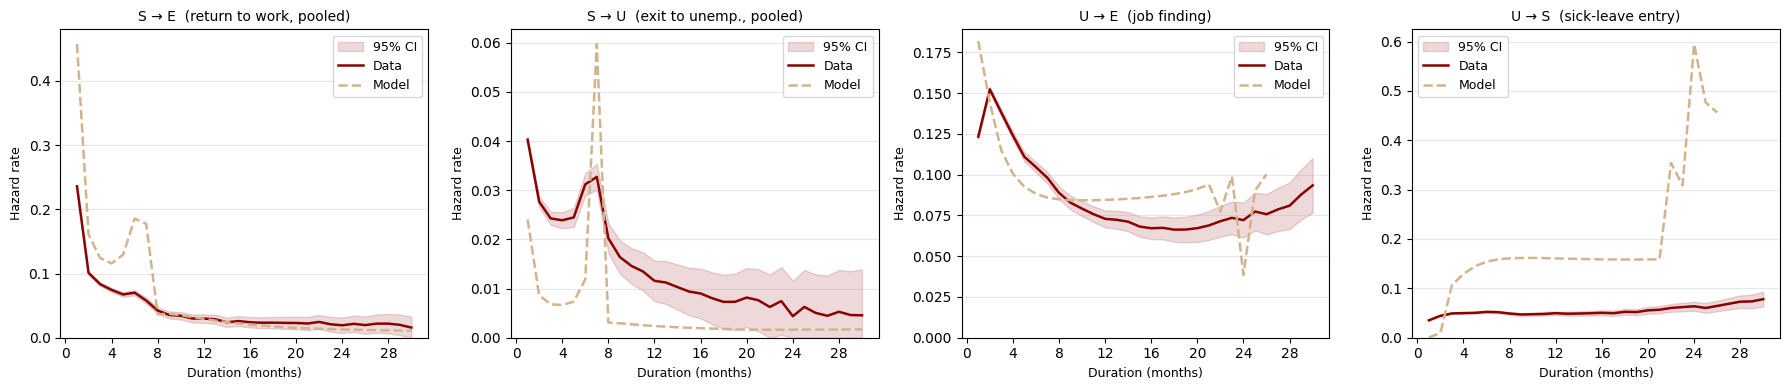

In [7]:
est.plot_fit(theta0, data_moments, raw_data=raw_data)

## 7. Run estimation — two-step procedure

**Step 1** estimates all parameters with `w_avg` fixed.  
**Step 2+** after Step 1, compute the simulated average wage, update `w_avg` and benefit levels, then re-estimate warm-starting from the previous result. Repeat until `w_avg` converges (typically 2–3 rounds).

In [8]:

# ── Step 1: estimate with w_avg fixed ────────────────────────────────────────
print("=" * 60)
print("STEP 1: estimation with w_avg fixed")
print("=" * 60)

est.update_w_avg = False
result1 = est.estimate(
    data_moments,
    W        = W_se,
    theta0   = theta0,
    patience = 100,
)
print(result1['table'])

# ── Outer loop: re-calibrate w_avg, re-estimate until w_avg converges ────────
# Each outer iteration is cheap (no inner double-solve), typically 2-3 rounds.

w_avg_tol      = 1e-3
w_avg_max_iter = 5

result = result1
for outer in range(w_avg_max_iter):
    # compute simulated w_avg at current estimates
    model_cur = est._build_model(result['theta'])
    model_cur.solve()
    model_cur.simulate()
    w_avg_new = model_cur.avg_wage()

    diff = w_avg_new - est.calibrated['w_avg']
    print(f"\nOuter iter {outer + 1}: w_avg {est.calibrated['w_avg']:.4f} → {w_avg_new:.4f}  (diff = {diff:+.4f})")
    print(f"  b_wel = {0.40 * w_avg_new:.4f}   b_emp = {0.77 * w_avg_new:.4f}   bmax = {0.65 * w_avg_new:.4f}")

    if abs(diff) < w_avg_tol:
        print("  Converged.")
        break

    est.calibrated['w_avg'] = w_avg_new

    print(f"\n{'=' * 60}")
    print(f"STEP 2.{outer + 1}: re-estimation with updated w_avg = {w_avg_new:.4f}")
    print(f"{'=' * 60}")

    result = est.estimate(
        data_moments,
        W        = W_se,
        theta0   = result['theta'],   # warm-start from previous
        patience = 10,
    )

print("\nFinal estimates:")
print(result['table'])


STEP 1: estimation with w_avg fixed
Nelder-Mead  (26 parameters)  patience=100


/Users/sophiebune/Library/Mobile Documents/com~apple~CloudDocs/POLIT/Kandidat/Speciale/speciale/Code/DynLaborSickModel.py:593: RuntimeWarning: invalid value encountered in divide
  hazard = np.where(at_risk_out > 0, exits_E_out / at_risk_out, 0.0)
/Users/sophiebune/Library/Mobile Documents/com~apple~CloudDocs/POLIT/Kandidat/Speciale/speciale/Code/DynLaborSickModel.py:756: RuntimeWarning: invalid value encountered in divide
  hazard = np.where(at_risk_out > 0, exits_S_out / at_risk_out, 0.0)


  iter    1  |  best Q = 0.489042
  iter    2  |  best Q = 0.489042
  iter    3  |  best Q = 0.465031
  iter    4  |  best Q = 0.395989
  iter    5  |  best Q = 0.375429
  iter    6  |  best Q = 0.339407
  iter    7  |  best Q = 0.339407
  iter    8  |  best Q = 0.339407
  iter    9  |  best Q = 0.339407


/Users/sophiebune/Library/Mobile Documents/com~apple~CloudDocs/POLIT/Kandidat/Speciale/speciale/Code/DynLaborSickModel.py:892: RuntimeWarning: invalid value encountered in divide
  hz_E_Eorig = np.where(ar_E > 0, ex_E_Eorig / ar_E, 0.0)
/Users/sophiebune/Library/Mobile Documents/com~apple~CloudDocs/POLIT/Kandidat/Speciale/speciale/Code/DynLaborSickModel.py:893: RuntimeWarning: invalid value encountered in divide
  hz_U_Eorig = np.where(ar_E > 0, ex_U_Eorig / ar_E, 0.0)
/Users/sophiebune/Library/Mobile Documents/com~apple~CloudDocs/POLIT/Kandidat/Speciale/speciale/Code/DynLaborSickModel.py:894: RuntimeWarning: invalid value encountered in divide
  hz_U_Uorig = np.where(ar_U > 0, ex_U_Uorig / ar_U, 0.0)
/Users/sophiebune/Library/Mobile Documents/com~apple~CloudDocs/POLIT/Kandidat/Speciale/speciale/Code/DynLaborSickModel.py:895: RuntimeWarning: invalid value encountered in divide
  hz_E_Uorig = np.where(ar_U > 0, ex_E_Uorig / ar_U, 0.0)


  iter   10  |  best Q = 0.339407
  iter   11  |  best Q = 0.271077
  iter   12  |  best Q = 0.271077
  iter   13  |  best Q = 0.271077
  iter   14  |  best Q = 0.271077
  iter   15  |  best Q = 0.271077
  iter   16  |  best Q = 0.271077
  iter   17  |  best Q = 0.271077
  iter   18  |  best Q = 0.271077
  iter   19  |  best Q = 0.271077
  iter   20  |  best Q = 0.271077
  iter   21  |  best Q = 0.271077
  iter   22  |  best Q = 0.271077
  iter   23  |  best Q = 0.271077
  iter   24  |  best Q = 0.271077
  iter   25  |  best Q = 0.271077
  iter   26  |  best Q = 0.271077
  iter   27  |  best Q = 0.271077
  iter   28  |  best Q = 0.271077
  iter   29  |  best Q = 0.271077
  iter   30  |  best Q = 0.271077
  iter   31  |  best Q = 0.271077
  iter   32  |  best Q = 0.271077
  iter   33  |  best Q = 0.271077
  iter   34  |  best Q = 0.271077
  iter   35  |  best Q = 0.271077
  iter   36  |  best Q = 0.271077
  iter   37  |  best Q = 0.271077
  iter   38  |  best Q = 0.271077
  iter   39  |

KeyboardInterrupt: 

## 8. Simulated vs empirical hazards at estimates

In [ ]:
est.plot_fit(result['theta'], data_moments, raw_data=raw_data)

## 9. Moment fit table

In [ ]:
fit = moment_fit_table(est.compute_moments(result['theta']), data_moments)
display(fit)

,data,model,deviation,rel_dev_%
moment,,,,
hz_se_d01,0.330428,0.393194,0.062766,18.995275
hz_se_d02,0.230212,0.230023,-0.000189,-0.082018
hz_se_d03,0.182215,0.199084,0.016869,9.257479
hz_se_d04,0.208169,0.181488,-0.026681,-12.817023
hz_se_d05,0.156924,0.171950,0.015026,9.575388
...,...,...,...,...
hz_us_d22,0.060326,0.283755,0.223429,370.371159
hz_us_d23,0.062078,0.289220,0.227141,365.894508
hz_us_d24,0.063676,0.475634,0.411958,646.958540


## 10. Re-estimation with optimal weighting matrix
Once you have a good first-round estimate, compute the efficient weighting matrix W* = Ω⁻¹  
and re-estimate. This up-weights precisely measured moments and gives correct standard errors.

In [ ]:

# W_opt   = est.optimal_weight_matrix(result['theta'], data_moments, n_bootstrap=200)
# result2 = est.estimate(data_moments, W=W_opt, theta0=result['theta'])
# est.plot_fit(result2['theta'], data_moments)


## 11. Standard errors

In [ ]:
# table = est.results_table(result['theta'], data_moments=data_moments,
#                            W=W_se, compute_se=True)
# display(table)